# Task
Develop a time series forecasting model for stock log returns using a GRU neural network. The process involves loading and merging financial data from "/content/JPM.csv", "/content/BAC.csv", "/content/WFC.csv", "/content/SPX500.csv", "/content/FED_RATE.csv", "/content/VIX.csv", and "/content/Sentiment.csv", calculating log returns, chronologically splitting the data into training, validation, and test sets (80%, 10%, 10%), scaling features, generating time series sequences with a 22-day sliding window, building and training a GRU model, performing recursive forecasting on the test set, evaluating performance using RMSE and MAPE, visualizing loss curves and actual vs. predicted log returns, and summarizing the entire pipeline.

## Load and Merge Financial Data

### Subtask:
Load 'JPM.csv', 'BAC.csv', 'WFC.csv', 'SPX500.csv', 'FED_RATE.csv', 'VIX.csv', and 'Sentiment.csv' into Pandas DataFrames. Merge these datasets into a single DataFrame based on their respective date columns, ensuring the resulting DataFrame is strictly sorted by date. Handle any potential missing dates or alignment issues during merging.


**Reasoning**:
First, I'll import the pandas library to handle data manipulation and then load the 'JPM.csv' file into a DataFrame. After loading, I'll convert the 'Date' column to datetime objects and set it as the index, as per the instructions.



In [1]:
import pandas as pd

# Load JPM.csv
jpm_df = pd.read_csv('JPM.csv')
jpm_df['Date'] = pd.to_datetime(jpm_df['Date'])
jpm_df = jpm_df.set_index('Date')

print("JPM DataFrame loaded and processed:")
print(jpm_df.head())

JPM DataFrame loaded and processed:
                       Open    High     Low   Close    Volume
Date                                                         
2018-01-02 16:00:00  107.63  108.02  106.81  107.95  13578835
2018-01-03 16:00:00  107.86  108.49  107.48  108.06  11901037
2018-01-04 16:00:00  108.36  110.03  108.20  109.04  12953656
2018-01-05 16:00:00  109.26  109.55  107.78  108.34  14154974
2018-01-08 16:00:00  108.15  108.68  107.70  108.50  12466512


**Reasoning**:
Now that 'JPM.csv' has been loaded and processed, I will load and process the next required file, 'BAC.csv', by converting its 'Date' column to datetime objects and setting it as the index.



In [2]:
bac_df = pd.read_csv('BAC.csv')
bac_df['Date'] = pd.to_datetime(bac_df['Date'])
bac_df = bac_df.set_index('Date')

print("BAC DataFrame loaded and processed:")
print(bac_df.head())

BAC DataFrame loaded and processed:
                      Open   High    Low  Close    Volume
Date                                                     
2018-01-02 16:00:00  29.75  29.90  29.61  29.90  57121603
2018-01-03 16:00:00  29.90  29.94  29.69  29.80  57865727
2018-01-04 16:00:00  29.97  30.44  29.88  30.19  76512451
2018-01-05 16:00:00  30.37  30.42  30.05  30.33  56445186
2018-01-08 16:00:00  30.23  30.27  30.05  30.12  42914839


**Reasoning**:
Following the pattern of the subtask, I will now load and process 'WFC.csv' by converting its 'Date' column to datetime objects and setting it as the index.



In [3]:
wfc_df = pd.read_csv('WFC.csv')
wfc_df['Date'] = pd.to_datetime(wfc_df['Date'])
wfc_df = wfc_df.set_index('Date')

print("WFC DataFrame loaded and processed:")
print(wfc_df.head())

WFC DataFrame loaded and processed:
                      Open   High    Low  Close    Volume
Date                                                     
2018-01-02 16:00:00  61.04  61.36  60.70  61.09  13819293
2018-01-03 16:00:00  61.22  61.77  61.10  61.56  14203721
2018-01-04 16:00:00  61.98  63.05  61.91  62.33  18740512
2018-01-05 16:00:00  62.76  62.81  62.09  62.75  14217871
2018-01-08 16:00:00  62.66  62.73  61.94  62.04  15569369


**Reasoning**:
Continuing with the subtask, I will now load and process 'SPX500.csv' by converting its 'Date' column to datetime objects and setting it as the index.



In [4]:
spx_df = pd.read_csv('SPX500.csv')
spx_df['Date'] = pd.to_datetime(spx_df['Date'])
spx_df = spx_df.set_index('Date')

print("SPX500 DataFrame loaded and processed:")
print(spx_df.head())

SPX500 DataFrame loaded and processed:
                  Close         High          Low         Open      Volume
Date                                                                      
2018-01-02  2695.810059  2695.889893  2682.360107  2683.729980  3397430000
2018-01-03  2713.060059  2714.370117  2697.770020  2697.850098  3544030000
2018-01-04  2723.989990  2729.290039  2719.070068  2719.310059  3697340000
2018-01-05  2743.149902  2743.449951  2727.919922  2731.330078  3239280000
2018-01-08  2747.709961  2748.510010  2737.600098  2742.669922  3246160000


**Reasoning**:
Continuing the process of loading and preprocessing the financial data, I will now load 'FED_RATE.csv', convert its 'Date' column to datetime objects, and set it as the DataFrame's index.



In [5]:
fed_rate_df = pd.read_csv('FED_RATE.csv')
fed_rate_df['Date'] = pd.to_datetime(fed_rate_df['Date'])
fed_rate_df = fed_rate_df.set_index('Date')

print("FED_RATE DataFrame loaded and processed:")
print(fed_rate_df.head())

FED_RATE DataFrame loaded and processed:
            EFFR
Date            
2018-01-02  1.42
2018-01-03  1.42
2018-01-04  1.42
2018-01-05  1.42
2018-01-08  1.42


**Reasoning**:
Continuing the process of loading and preprocessing the financial data, I will now load 'VIX.csv', convert its 'Date' column to datetime objects, and set it as the DataFrame's index.



In [6]:
vix_df = pd.read_csv('VIX.csv')
vix_df['Date'] = pd.to_datetime(vix_df['Date'])
vix_df = vix_df.set_index('Date')

print("VIX DataFrame loaded and processed:")
print(vix_df.head())

VIX DataFrame loaded and processed:
            Close   High   Low   Open  Volume
Date                                         
2018-01-02   9.77  11.07  9.52  10.95       0
2018-01-03   9.15   9.65  8.94   9.56       0
2018-01-04   9.22   9.31  8.92   9.01       0
2018-01-05   9.22   9.54  9.00   9.10       0
2018-01-08   9.52   9.89  9.32   9.61       0


**Reasoning**:
Following the pattern of the subtask, I will now load and process 'Sentiment.csv' by converting its 'Date' column to datetime objects and setting it as the index.



In [7]:
sentiment_df = pd.read_csv('Sentiment.csv')
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date'])
sentiment_df = sentiment_df.set_index('Date')

print("Sentiment DataFrame loaded and processed:")
print(sentiment_df.head())

Sentiment DataFrame loaded and processed:
            BAC_news_count  JPM_news_count  WFC_news_count  BAC_avg_sentiment  \
Date                                                                            
2022-05-03               0               0               1              0.000   
2024-10-30               1               0               0              6.369   
2024-11-03               1               0               1              6.369   
2024-11-17               2               0               0              0.000   
2024-11-18               5               6               5             15.608   

            JPM_avg_sentiment WFC_avg_sentiment  
Date                                             
2022-05-03              0.000             6.249  
2024-10-30              0.000                 0  
2024-11-03              0.000             6.369  
2024-11-17              0.000                 0  
2024-11-18            227.033            31.142  


**Reasoning**:
Now that all individual DataFrames ('jpm_df', 'bac_df', 'wfc_df', 'spx_df', 'fed_rate_df', 'vix_df', 'sentiment_df') have been loaded and preprocessed with 'Date' as their index, I will merge them into a single DataFrame using an outer join to include all dates and handle missing values, and then sort the final merged DataFrame chronologically by its date index.



In [8]:
merged_df = jpm_df.copy()
merged_df = merged_df.merge(bac_df, on='Date', how='outer', suffixes=('_JPM', '_BAC'))
merged_df = merged_df.merge(wfc_df, on='Date', how='outer', suffixes=('_BAC', '_WFC'))
merged_df = merged_df.merge(spx_df, on='Date', how='outer', suffixes=('_WFC', '_SPX'))
merged_df = merged_df.merge(fed_rate_df, on='Date', how='outer')
merged_df = merged_df.merge(vix_df, on='Date', how='outer', suffixes=('_FED', '_VIX'))
merged_df = merged_df.merge(sentiment_df, on='Date', how='outer', suffixes=('_VIX', '_Sentiment'))

merged_df = merged_df.sort_index()

print("Merged DataFrame head:")
print(merged_df.head())
print("\nMerged DataFrame tail:")
print(merged_df.tail())
print("\nMerged DataFrame info:")
merged_df.info()

Merged DataFrame head:
                     Open_JPM  High_JPM  Low_JPM  Close_JPM  Volume_JPM  \
Date                                                                      
2018-01-02 00:00:00       NaN       NaN      NaN        NaN         NaN   
2018-01-02 16:00:00    107.63    108.02   106.81     107.95  13578835.0   
2018-01-03 00:00:00       NaN       NaN      NaN        NaN         NaN   
2018-01-03 16:00:00    107.86    108.49   107.48     108.06  11901037.0   
2018-01-04 00:00:00       NaN       NaN      NaN        NaN         NaN   

                     Open_BAC  High_BAC  Low_BAC  Close_BAC  Volume_BAC  ...  \
Date                                                                     ...   
2018-01-02 00:00:00       NaN       NaN      NaN        NaN         NaN  ...   
2018-01-02 16:00:00     29.75     29.90    29.61       29.9  57121603.0  ...   
2018-01-03 00:00:00       NaN       NaN      NaN        NaN         NaN  ...   
2018-01-03 16:00:00     29.90     29.94    29.69   

## Calculate Log Returns and Prepare Features

### Subtask:
For each stock (JPM, BAC, WFC) and SPX500, calculate the daily log returns and designate them as target variables. Prepare other features from VIX, FED_RATE, and Sentiment. Handle any NaN values that might arise from log return calculation.


**Reasoning**:
The 'WFC_avg_sentiment' column was loaded as an object type, as observed in the `merged_df.info()` output. To use it in numerical calculations, I need to convert it to a numeric type, coercing any non-convertible values to NaN, as specified in the instructions.



In [9]:
merged_df['WFC_avg_sentiment'] = pd.to_numeric(merged_df['WFC_avg_sentiment'], errors='coerce')

print("Converted 'WFC_avg_sentiment' to numeric type.")
print(merged_df[['WFC_avg_sentiment']].head())

Converted 'WFC_avg_sentiment' to numeric type.
                     WFC_avg_sentiment
Date                                  
2018-01-02 00:00:00                NaN
2018-01-02 16:00:00                NaN
2018-01-03 00:00:00                NaN
2018-01-03 16:00:00                NaN
2018-01-04 00:00:00                NaN


**Reasoning**:
Now that the 'WFC_avg_sentiment' column is numeric, I will proceed to calculate the daily log returns for the 'Close' prices of JPM, BAC, WFC, and SPX500 as instructed, storing them in new columns within the `merged_df`.



In [10]:
import numpy as np

merged_df['Log_Return_JPM'] = np.log(merged_df['Close_JPM']).diff()
merged_df['Log_Return_BAC'] = np.log(merged_df['Close_BAC']).diff()
merged_df['Log_Return_WFC'] = np.log(merged_df['Close_WFC']).diff()
merged_df['Log_Return_SPX'] = np.log(merged_df['Close_SPX']).diff()

print("Log returns calculated and added to merged_df:")
print(merged_df[['Close_JPM', 'Log_Return_JPM', 'Close_BAC', 'Log_Return_BAC', 'Close_WFC', 'Log_Return_WFC', 'Close_SPX', 'Log_Return_SPX']].head(10))

Log returns calculated and added to merged_df:
                     Close_JPM  Log_Return_JPM  Close_BAC  Log_Return_BAC  \
Date                                                                        
2018-01-02 00:00:00        NaN             NaN        NaN             NaN   
2018-01-02 16:00:00     107.95             NaN      29.90             NaN   
2018-01-03 00:00:00        NaN             NaN        NaN             NaN   
2018-01-03 16:00:00     108.06             NaN      29.80             NaN   
2018-01-04 00:00:00        NaN             NaN        NaN             NaN   
2018-01-04 16:00:00     109.04             NaN      30.19             NaN   
2018-01-05 00:00:00        NaN             NaN        NaN             NaN   
2018-01-05 16:00:00     108.34             NaN      30.33             NaN   
2018-01-08 00:00:00        NaN             NaN        NaN             NaN   
2018-01-08 16:00:00     108.50             NaN      30.12             NaN   

                     Close_W

**Reasoning**:
Now that log returns are calculated, I will select the specified features, rename the VIX Close column to 'Close_VIX' to avoid potential naming conflicts, and compile them into a new DataFrame called `processed_df` as instructed.



In [11]:
merged_df = merged_df.rename(columns={'Close': 'Close_VIX'}) # Rename VIX's Close column

feature_columns = [
    'Log_Return_JPM',
    'Log_Return_BAC',
    'Log_Return_WFC',
    'Log_Return_SPX',
    'Close_VIX', # VIX Close price
    'EFFR', # FED_RATE
    'BAC_news_count',
    'JPM_news_count',
    'WFC_news_count',
    'BAC_avg_sentiment',
    'JPM_avg_sentiment',
    'WFC_avg_sentiment'
]

processed_df = merged_df[feature_columns].copy()

print("Processed DataFrame created with selected features:")
print(processed_df.head())

Processed DataFrame created with selected features:
                     Log_Return_JPM  Log_Return_BAC  Log_Return_WFC  \
Date                                                                  
2018-01-02 00:00:00             NaN             NaN             NaN   
2018-01-02 16:00:00             NaN             NaN             NaN   
2018-01-03 00:00:00             NaN             NaN             NaN   
2018-01-03 16:00:00             NaN             NaN             NaN   
2018-01-04 00:00:00             NaN             NaN             NaN   

                     Log_Return_SPX  Close_VIX  EFFR  BAC_news_count  \
Date                                                                   
2018-01-02 00:00:00             NaN       9.77  1.42             NaN   
2018-01-02 16:00:00             NaN        NaN   NaN             NaN   
2018-01-03 00:00:00             NaN       9.15  1.42             NaN   
2018-01-03 16:00:00             NaN        NaN   NaN             NaN   
2018-01-04 00:00:0

**Reasoning**:
To handle any remaining NaN values in the `processed_df` after calculating log returns and selecting features, I will apply forward-fill (`ffill`) followed by backward-fill (`bfill`). This ensures that missing values are imputed using existing data points, preserving the chronological order as instructed, and then I will print the head, tail, and info to confirm the imputation and check data types and non-null counts.



In [12]:
processed_df = processed_df.ffill().bfill()

print("Processed DataFrame after filling NaNs - head:")
print(processed_df.head())
print("\nProcessed DataFrame after filling NaNs - tail:")
print(processed_df.tail())
print("\nProcessed DataFrame after filling NaNs - info:")
processed_df.info()

Processed DataFrame after filling NaNs - head:
                     Log_Return_JPM  Log_Return_BAC  Log_Return_WFC  \
Date                                                                  
2018-01-02 00:00:00             NaN             NaN             NaN   
2018-01-02 16:00:00             NaN             NaN             NaN   
2018-01-03 00:00:00             NaN             NaN             NaN   
2018-01-03 16:00:00             NaN             NaN             NaN   
2018-01-04 00:00:00             NaN             NaN             NaN   

                     Log_Return_SPX  Close_VIX  EFFR  BAC_news_count  \
Date                                                                   
2018-01-02 00:00:00             NaN       9.77  1.42             0.0   
2018-01-02 16:00:00             NaN       9.77  1.42             0.0   
2018-01-03 00:00:00             NaN       9.15  1.42             0.0   
2018-01-03 16:00:00             NaN       9.15  1.42             0.0   
2018-01-04 00:00:00    

**Reasoning**:
The previous log return calculation resulted in all NaN values because `merged_df` contained multiple entries for the same date (e.g., '00:00:00' and '16:00:00' timestamps), leading to incorrect `diff()` computations across mixed-timestamp rows. To fix this and ensure daily log returns are accurately calculated, I need to first resample the `merged_df` to a daily frequency, taking the last available observation for each day. This will consolidate the data to a single daily entry, after which the log returns can be correctly computed.



In [13]:
merged_df = merged_df.resample('D').last()

merged_df['Log_Return_JPM'] = np.log(merged_df['Close_JPM']).diff()
merged_df['Log_Return_BAC'] = np.log(merged_df['Close_BAC']).diff()
merged_df['Log_Return_WFC'] = np.log(merged_df['Close_WFC']).diff()
merged_df['Log_Return_SPX'] = np.log(merged_df['Close_SPX']).diff()

# Rename VIX's Close column to avoid ambiguity since it's already done before
merged_df = merged_df.rename(columns={'Close': 'Close_VIX'})

feature_columns = [
    'Log_Return_JPM',
    'Log_Return_BAC',
    'Log_Return_WFC',
    'Log_Return_SPX',
    'Close_VIX', # VIX Close price
    'EFFR', # FED_RATE
    'BAC_news_count',
    'JPM_news_count',
    'WFC_news_count',
    'BAC_avg_sentiment',
    'JPM_avg_sentiment',
    'WFC_avg_sentiment'
]

processed_df = merged_df[feature_columns].copy()

# Fill any remaining NaNs after resampling and log return calculation
processed_df = processed_df.ffill().bfill()

print("Processed DataFrame after resampling, log return calculation, and NaN filling - head:")
print(processed_df.head())
print("\nProcessed DataFrame after resampling, log return calculation, and NaN filling - tail:")
print(processed_df.tail())
print("\nProcessed DataFrame after resampling, log return calculation, and NaN filling - info:")
processed_df.info()

Processed DataFrame after resampling, log return calculation, and NaN filling - head:
            Log_Return_JPM  Log_Return_BAC  Log_Return_WFC  Log_Return_SPX  \
Date                                                                         
2018-01-02        0.001018       -0.003350        0.007664        0.006378   
2018-01-03        0.001018       -0.003350        0.007664        0.006378   
2018-01-04        0.009028        0.013002        0.012431        0.004021   
2018-01-05       -0.006440        0.004627        0.006716        0.007009   
2018-01-06       -0.006440        0.004627        0.006716        0.007009   

            Close_VIX  EFFR  BAC_news_count  JPM_news_count  WFC_news_count  \
Date                                                                          
2018-01-02       9.77  1.42             0.0             0.0             1.0   
2018-01-03       9.15  1.42             0.0             0.0             1.0   
2018-01-04       9.22  1.42             0.0        

## Perform Chronological Data Splitting

### Subtask:
Split the merged and processed dataset into training (80%), validation (10%), and testing (10%) sets strictly chronologically. Ensure no data shuffling occurs and that validation follows training, and testing follows validation.


**Reasoning**:
I will calculate the indices for splitting the `processed_df` into training, validation, and test sets based on the specified 80%, 10%, and 10% chronological proportions and then create the respective DataFrames and print their shapes to verify the split.



In [14]:
total_rows = len(processed_df)

train_size = int(total_rows * 0.8)
val_size = int(total_rows * 0.1)
test_size = total_rows - train_size - val_size # Ensure all rows are covered

# Split the DataFrame chronologically
train_df = processed_df.iloc[:train_size].copy()
val_df = processed_df.iloc[train_size:train_size + val_size].copy()
test_df = processed_df.iloc[train_size + val_size:].copy()

print(f"Shape of training set: {train_df.shape}")
print(f"Shape of validation set: {val_df.shape}")
print(f"Shape of test set: {test_df.shape}")

Shape of training set: (2296, 12)
Shape of validation set: (287, 12)
Shape of test set: (288, 12)


## Scale Features

### Subtask:
Apply a suitable scaler (e.g., MinMaxScaler or StandardScaler) to the features. Crucially, fit the scaler only on the training data's features and then transform the features of the training, validation, and test sets using this fitted scaler.


**Reasoning**:
To begin scaling the features, I will import the `MinMaxScaler` from `sklearn.preprocessing`, as instructed, which is necessary for normalizing the data.



In [15]:
from sklearn.preprocessing import MinMaxScaler

print("MinMaxScaler imported.")

MinMaxScaler imported.


**Reasoning**:
Now that `MinMaxScaler` has been imported, I will instantiate it, fit it to the training data, and then transform the training, validation, and test sets, as instructed by the subtask.



In [16]:
scaler = MinMaxScaler()

# Fit the scaler only on the training data and transform
train_df_scaled = scaler.fit_transform(train_df)
val_df_scaled = scaler.transform(val_df)
test_df_scaled = scaler.transform(test_df)

# Convert scaled arrays back to DataFrames, preserving index and columns
train_df = pd.DataFrame(train_df_scaled, columns=train_df.columns, index=train_df.index)
val_df = pd.DataFrame(val_df_scaled, columns=val_df.columns, index=val_df.index)
test_df = pd.DataFrame(test_df_scaled, columns=test_df.columns, index=test_df.index)

print("Scaled training set head:")
print(train_df.head())
print("\nScaled validation set head:")
print(val_df.head())
print("\nScaled test set head:")
print(test_df.head())

Scaled training set head:
            Log_Return_JPM  Log_Return_BAC  Log_Return_WFC  Log_Return_SPX  \
Date                                                                         
2018-01-02        0.405452        0.379977        0.584930        0.560694   
2018-01-03        0.405452        0.379977        0.584930        0.560694   
2018-01-04        0.434384        0.440640        0.600381        0.548259   
2018-01-05        0.378511        0.409568        0.581856        0.564020   
2018-01-06        0.378511        0.409568        0.581856        0.564020   

            Close_VIX     EFFR  BAC_news_count  JPM_news_count  \
Date                                                             
2018-01-02   0.008431  0.26087             0.0             0.0   
2018-01-03   0.000000  0.26087             0.0             0.0   
2018-01-04   0.000952  0.26087             0.0             0.0   
2018-01-05   0.000952  0.26087             0.0             0.0   
2018-01-06   0.000952  0.26087 

## Generate Time Series Sequences

### Subtask:
Create input sequences (X) and corresponding target values (y) for each of the training, validation, and test sets. Use a sliding window of 22 trading days for input (X) to predict the next day's log return (y). Ensure there is no overlap in data used for sequence generation across the splits to prevent data leakage.


**Reasoning**:
To generate the time series sequences for the GRU model, I need to define a function `create_sequences` that will iterate through the input DataFrame, create input sequences (X) of `look_back` days, and extract the corresponding target values (y) from the specified log return columns for the day immediately following each sequence. This function will be crucial for preparing the data for model training.



In [17]:
import numpy as np

def create_sequences(df, look_back):
    X, y = [], []
    target_columns = ['Log_Return_JPM', 'Log_Return_BAC', 'Log_Return_WFC']
    for i in range(len(df) - look_back):
        X.append(df.iloc[i:(i + look_back)].values)
        y.append(df.iloc[i + look_back][target_columns].values)
    return np.array(X), np.array(y)

print("create_sequences function defined.")

create_sequences function defined.


**Reasoning**:
Now that the `create_sequences` function is defined, I will apply it to the `train_df`, `val_df`, and `test_df` with a `look_back` of 22, as specified, to generate the input sequences (X) and target values (y) for each dataset. Then, I will print the shapes of these arrays to verify the correct dimensions.



In [18]:
look_back = 22

X_train, y_train = create_sequences(train_df, look_back)
X_val, y_val = create_sequences(val_df, look_back)
X_test, y_test = create_sequences(test_df, look_back)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2274, 22, 12)
Shape of y_train: (2274, 3)
Shape of X_val: (265, 22, 12)
Shape of y_val: (265, 3)
Shape of X_test: (266, 22, 12)
Shape of y_test: (266, 3)


## Build GRU Model Architecture

### Subtask:
Construct a GRU-based neural network model using TensorFlow/Keras. This model should include stacked GRU layers, dropout for regularization, and a dense output layer suitable for one-step-ahead forecasting.


**Reasoning**:
To construct the GRU model as specified, I will import the necessary Keras layers, initialize a Sequential model, and then add stacked GRU layers with dropout, followed by a Dense output layer for the three target variables. Finally, I'll print the model summary to confirm the architecture.



In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense

# Define model parameters based on data shapes
num_timesteps = X_train.shape[1] # look_back = 22
num_features = X_train.shape[2] # Number of features in each timestep
num_targets = y_train.shape[1]  # Number of target log returns (JPM, BAC, WFC)

# Initialize the Sequential model
model = Sequential()

# Add the first GRU layer with return_sequences=True for stacking GRU layers
model.add(GRU(units=50, return_sequences=True, input_shape=(num_timesteps, num_features)))
# Add a Dropout layer for regularization
model.add(Dropout(0.2))

# Add a second GRU layer with return_sequences=False as it's the last GRU layer
model.add(GRU(units=50, return_sequences=False))
# Add another Dropout layer
model.add(Dropout(0.2))

# Add the Dense output layer with 3 units for the three target log returns
model.add(Dense(units=num_targets))

# Print the model summary to review its architecture
print("GRU Model Architecture:")
model.summary()


GRU Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 22, 50)         │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,053 (97.86 KB)

 Trainable params: 25,053 (97.86 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The GRU model architecture has been successfully defined. The next logical step, according to the overall task, is to compile the model, which involves specifying the optimizer, loss function, and metrics to be used during training.



In [20]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_percentage_error'])

print("GRU Model compiled with Adam optimizer and Mean Squared Error loss.")

GRU Model compiled with Adam optimizer and Mean Squared Error loss.


## Compile and Train GRU Model

### Subtask:
Train the GRU model on the training data, monitoring its performance on the validation data.


**Reasoning**:
I will now train the GRU model using the `fit()` method, providing the training and validation datasets, specifying the number of epochs and batch size, and storing the training history.



In [21]:
epochs = 100
batch_size = 32

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    verbose=1
)

print(f"Model trained for {epochs} epochs with a batch size of {batch_size}.")

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 0.0309 - mean_absolute_percentage_error: 110319.5391 - val_loss: 0.0782 - val_mean_absolute_percentage_error: 34.0579
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0096 - mean_absolute_percentage_error: 577037.2500 - val_loss: 0.0695 - val_mean_absolute_percentage_error: 30.8594
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0096 - mean_absolute_percentage_error: 675244.3750 - val_loss: 0.0599 - val_mean_absolute_percentage_error: 28.3860
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0079 - mean_absolute_percentage_error: 318671.7812 - val_loss: 0.0560 - val_mean_absolute_percentage_error: 27.3606
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0072 - mean_absolute_percentage_error: 253555.6562 - val_loss: 0.0521 - val_mean_absolute_percentage_error: 26.6934
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0067 - mean_absolute_percentage_error: 224280.32

In [24]:
import numpy as np

# Dictionary lưu kết quả forecast
forecast_results = {}

# Dự báo one-step-ahead trên tập test
y_test_pred = model.predict(X_test)

# Lưu kết quả (KHÔNG inverse-scale vì target đã ở scale log-return)
forecast_results['actual'] = y_test
forecast_results['predicted'] = y_test_pred

print("Rolling one-step-ahead forecasting completed.")
print("Actual shape:", y_test.shape)
print("Predicted shape:", y_test_pred.shape)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step
Rolling one-step-ahead forecasting completed.
Actual shape: (266, 3)
Predicted shape: (266, 3)


In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import pandas as pd

targets = ['Log_Return_JPM', 'Log_Return_BAC', 'Log_Return_WFC']

evaluation_results = {}

for i, target in enumerate(targets):
    y_true = forecast_results['actual'][:, i]
    y_pred = forecast_results['predicted'][:, i]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    evaluation_results[target] = {
        'RMSE': rmse,
        'MAPE (%)': mape
    }

    print(f"\n--- Evaluation for {target} ---")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAPE : {mape:.2f}%")

# Tổng hợp bảng
evaluation_df = pd.DataFrame(evaluation_results).T
evaluation_df



--- Evaluation for Log_Return_JPM ---
RMSE : 0.371089
MAPE : 78.40%

--- Evaluation for Log_Return_BAC ---
RMSE : 0.327927
MAPE : 79.60%

--- Evaluation for Log_Return_WFC ---
RMSE : 0.294898
MAPE : 43.57%


,RMSE,MAPE (%)
Log_Return_JPM,0.371089,78.402335
Log_Return_BAC,0.327927,79.601420
Log_Return_WFC,0.294898,43.568594


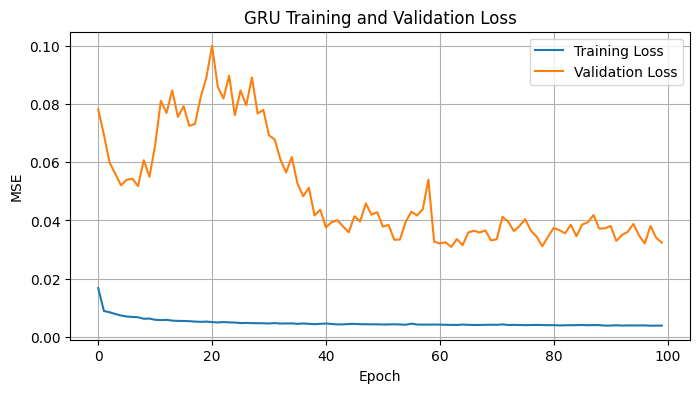

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('GRU Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()


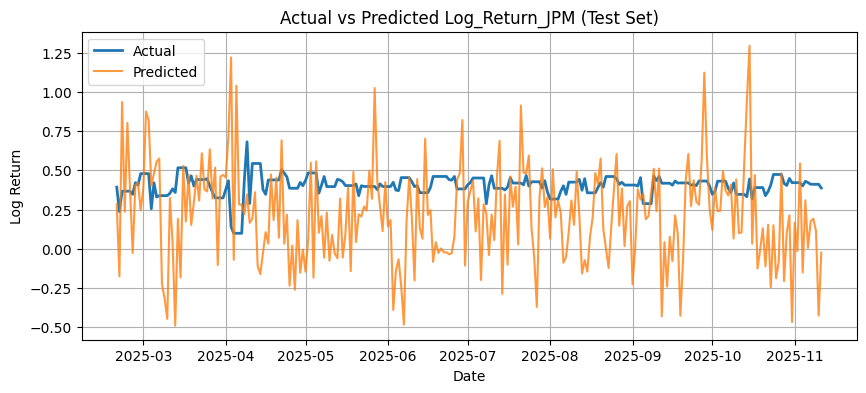

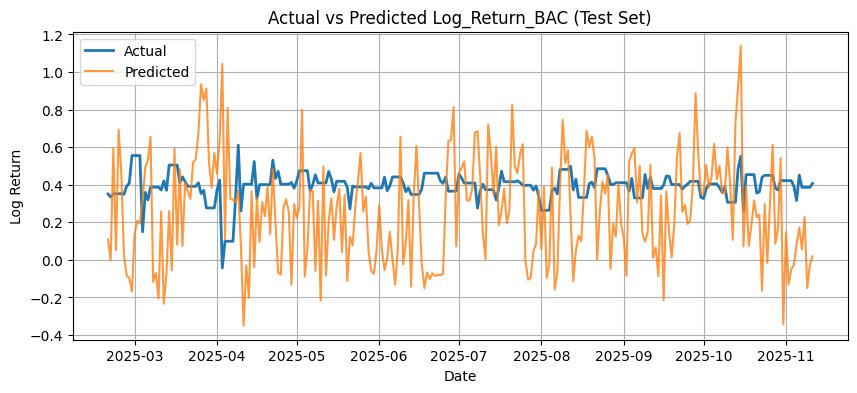

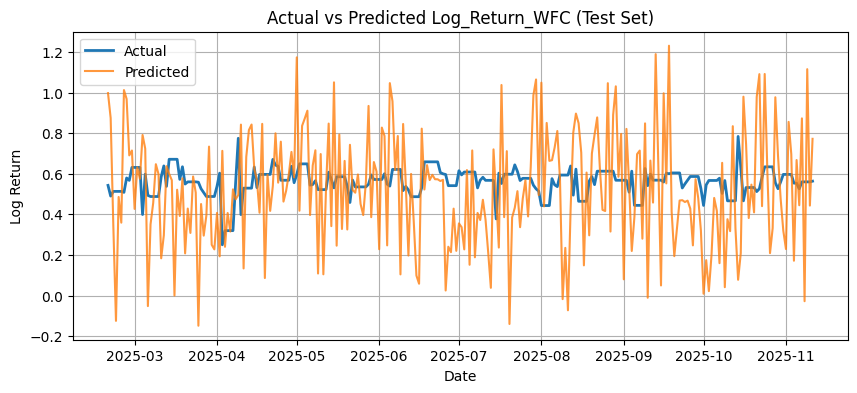

In [27]:
test_dates = test_df.index[look_back:]  # align với y_test

for i, target in enumerate(targets):
    plt.figure(figsize=(10,4))
    plt.plot(test_dates, forecast_results['actual'][:, i], label='Actual', linewidth=2)
    plt.plot(test_dates, forecast_results['predicted'][:, i], label='Predicted', alpha=0.8)

    plt.title(f'Actual vs Predicted {target} (Test Set)')
    plt.xlabel('Date')
    plt.ylabel('Log Return')
    plt.legend()
    plt.grid(True)
    plt.show()
